# Linear Regression for Sales Prediction
### Internship Project — Data Science and Analytics Track

---

## Project Overview

This project builds a Linear Regression model to predict total daily retail store sales.
The model uses date-based features, promotional data, and national holiday flags to learn
patterns in historical sales and generate predictions for future dates.

**Dataset:** [Kaggle — Store Sales Time Series Forecasting](https://www.kaggle.com/competitions/store-sales-time-series-forecasting)

---

## Learning Objectives

| # | Objective |
|---|-----------|
| 1 | Load and preprocess real-world retail sales data |
| 2 | Perform feature engineering on date and time columns |
| 3 | Merge multiple datasets (sales and holidays) |
| 4 | Build and evaluate a Linear Regression model |
| 5 | Visualize results professionally |
| 6 | Generate sales predictions for business scenarios |

---

## Files Used

| File | Purpose |
|------|---------|
| `train.csv` | Core dataset — daily sales per store per product family |
| `stores.csv` | Store metadata — type, city, state, cluster |
| `holidays_events.csv` | National and regional holiday flags |

---

## Tech Stack

Python | Pandas | NumPy | Scikit-learn | Matplotlib | Seaborn | Joblib

---

> **Track:** Data Science and Analytics | **Task:** Sales Prediction (Task 3) | **Dataset:** Corporacion Favorita (Kaggle)

---
## Section 1 — Library Imports

All required libraries are imported here. Each serves a specific role in the
data loading, processing, modeling, or visualization pipeline.


In [1]:
# Standard Library
import os
import warnings
warnings.filterwarnings('ignore')

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Model Persistence
import joblib

# Display Settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print("=" * 55)
print("   All libraries imported successfully!")
print("=" * 55)
print(f"   Pandas     : {pd.__version__}")
print(f"   NumPy      : {np.__version__}")
print(f"   Scikit-learn: (imported)")
print("=" * 55)


   All libraries imported successfully!
   Pandas     : 2.2.2
   NumPy      : 1.26.4
   Scikit-learn: (imported)


---
## Section 2 — Project Configuration

All file paths and global settings are defined in this single cell.
If files are moved or renamed, only this cell needs to be updated.

**Note:** This notebook and all required CSV files should be placed inside
the same folder (`Internship Projects/`). The path `"."` refers to that folder.


In [2]:
# Base Directory
# The notebook is inside "Internship Projects/" folder
# All CSV files should also be in the same folder
# "." means "current directory" = Internship Projects/
BASE_DIR = "."

# Input File Paths
TRAIN_PATH      = os.path.join(BASE_DIR, "train.csv")
STORES_PATH     = os.path.join(BASE_DIR, "stores.csv")
HOLIDAYS_PATH   = os.path.join(BASE_DIR, "holidays_events.csv")

# Output Directory
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Model Save Path
MODEL_PATH = os.path.join(OUTPUT_DIR, "linear_regression_model.pkl")

# Random Seed (for reproducibility)
RANDOM_SEED = 42

# Train-Test Split Ratio
TEST_SIZE = 0.2  # 80% train, 20% test

# Verify Files Exist
print("=" * 55)
print("   Project Configuration")
print("=" * 55)

files = {
    "train.csv": TRAIN_PATH,
    "stores.csv": STORES_PATH,
    "holidays_events.csv": HOLIDAYS_PATH,
}

all_ok = True
for name, path in files.items():
    exists = os.path.exists(path)
    status = " Found" if exists else " NOT FOUND"
    print(f"  {status}  →  {name}")
    if not exists:
        all_ok = False

print("-" * 55)
print(f"   Output folder   : {OUTPUT_DIR}")
print(f"   Model save path : {MODEL_PATH}")
print("=" * 55)

if not all_ok:
    print()
    print("  ⚠  WARNING: One or more CSV files are missing!")
    print("  Please download them from Kaggle and place them")
    print("  inside your 'Internship Projects' folder.")
else:
    print("   All files found! Ready to proceed.")


   Project Configuration
   Found  →  train.csv
   Found  →  stores.csv
   Found  →  holidays_events.csv
-------------------------------------------------------
   Output folder   : .\outputs
   Model save path : .\outputs\linear_regression_model.pkl
   All files found! Ready to proceed.


---
## Section 3 — Data Loading

### About the Dataset

The Store Sales — Time Series Forecasting dataset is sourced from Corporacion Favorita,
a major Ecuadorian grocery retailer. It contains transactional sales data across
54 stores and 33 product families from January 2013 to August 2017.

| File | Rows | Key Columns |
|------|------|-------------|
| `train.csv` | ~3M | date, store_nbr, family, sales, onpromotion |
| `stores.csv` | 54 | store_nbr, city, state, type, cluster |
| `holidays_events.csv` | 350 | date, type, locale, description, transferred |

### Aggregation Strategy

The raw `train.csv` has approximately 3 million rows — one record per store,
per product family, per day. For a regression model focused on national-level
trend and seasonality, we aggregate all records by date, producing one row per
day (~1,688 rows total). This simplification keeps the modeling approach clean
and interpretable.


In [3]:
# Load Raw Data
print("Loading datasets... (this may take 30-60 seconds for train.csv)")
print("-" * 50)

# Load train.csv — parse 'date' column as datetime automatically
train_raw = pd.read_csv(
    TRAIN_PATH,
    parse_dates=['date'],
    dtype={'store_nbr': 'int8', 'onpromotion': 'int32'}
)
print(f"   train.csv loaded        → Shape: {train_raw.shape}")

# Load stores.csv
stores = pd.read_csv(STORES_PATH)
print(f"   stores.csv loaded       → Shape: {stores.shape}")

# Load holidays_events.csv
holidays_raw = pd.read_csv(HOLIDAYS_PATH, parse_dates=['date'])
print(f"   holidays_events.csv loaded → Shape: {holidays_raw.shape}")

print("-" * 50)
print("   All datasets loaded successfully!")


Loading datasets... (this may take 30-60 seconds for train.csv)
--------------------------------------------------
   train.csv loaded        → Shape: (3000888, 6)
   stores.csv loaded       → Shape: (54, 5)
   holidays_events.csv loaded → Shape: (350, 6)
--------------------------------------------------
   All datasets loaded successfully!


### Dataset Preview


In [4]:
# Preview: train.csv
print("  TRAIN.CSV — First 5 rows:")
print("=" * 70)
display(train_raw.head())
print(f"\n Date range: {train_raw['date'].min().date()} → {train_raw['date'].max().date()}")
print(f" Total records: {len(train_raw):,}")
print(f" Unique stores: {train_raw['store_nbr'].nunique()}")
print(f"  Unique product families: {train_raw['family'].nunique()}")


  TRAIN.CSV — First 5 rows:


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.00,0
1,1,2013-01-01,1,BABY CARE,0.00,0
2,2,2013-01-01,1,BEAUTY,0.00,0
3,3,2013-01-01,1,BEVERAGES,0.00,0
4,4,2013-01-01,1,BOOKS,0.00,0



 Date range: 2013-01-01 → 2017-08-15
 Total records: 3,000,888
 Unique stores: 54
  Unique product families: 33


In [5]:
# Preview: stores.csv
print(" STORES.CSV — All stores:")
print("=" * 70)
display(stores.head(10))
print(f"\n Store types available: {stores['type'].unique()}")
print(f" Unique cities: {stores['city'].nunique()}")


 STORES.CSV — All stores:


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4
5,6,Quito,Pichincha,D,13
6,7,Quito,Pichincha,D,8
7,8,Quito,Pichincha,D,8
8,9,Quito,Pichincha,B,6
9,10,Quito,Pichincha,C,15



 Store types available: ['D' 'B' 'C' 'E' 'A']
 Unique cities: 22


In [6]:
# Preview: holidays_events.csv
print(" HOLIDAYS_EVENTS.CSV — First 10 rows:")
print("=" * 70)
display(holidays_raw.head(10))
print(f"\n Holiday types: {holidays_raw['type'].unique()}")
print(f" Locale types: {holidays_raw['locale'].unique()}")
print(f" Total holiday records: {len(holidays_raw)}")


 HOLIDAYS_EVENTS.CSV — First 10 rows:


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
5,2012-05-12,Holiday,Local,Puyo,Cantonizacion del Puyo,False
6,2012-06-23,Holiday,Local,Guaranda,Cantonizacion de Guaranda,False
7,2012-06-25,Holiday,Regional,Imbabura,Provincializacion de Imbabura,False
8,2012-06-25,Holiday,Local,Latacunga,Cantonizacion de Latacunga,False
9,2012-06-25,Holiday,Local,Machala,Fundacion de Machala,False



 Holiday types: ['Holiday' 'Transfer' 'Additional' 'Bridge' 'Work Day' 'Event']
 Locale types: ['Local' 'Regional' 'National']
 Total holiday records: 350


---
## Section 4 — Exploratory Data Analysis

Before building any model, the data must be examined carefully.
EDA reveals missing values, data types, value ranges, and potential
anomalies that would affect modeling decisions.


In [7]:
# Basic Info
print("=" * 60)
print("   TRAIN.CSV — Data Info")
print("=" * 60)
print(f"  Shape         : {train_raw.shape[0]:,} rows × {train_raw.shape[1]} columns")
print(f"  Memory usage  : {train_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()
print(train_raw.dtypes.to_string())
print()

# Missing values check
missing = train_raw.isnull().sum()
missing_pct = (missing / len(train_raw)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print("   No missing values in train.csv!")
else:
    print("  ⚠  Missing Values Found:")
    display(missing_df)


   TRAIN.CSV — Data Info
  Shape         : 3,000,888 rows × 6 columns
  Memory usage  : 266.4 MB

id                      int64
date           datetime64[ns]
store_nbr                int8
family                 object
sales                 float64
onpromotion             int32

   No missing values in train.csv!


In [8]:
# Sales Statistics
print("=" * 60)
print("   Sales Column — Descriptive Statistics")
print("=" * 60)
stats = train_raw['sales'].describe()
print(f"  Count  : {stats['count']:>15,.0f}")
print(f"  Mean   : {stats['mean']:>15,.2f}")
print(f"  Std Dev: {stats['std']:>15,.2f}")
print(f"  Min    : {stats['min']:>15,.2f}")
print(f"  25%    : {stats['25%']:>15,.2f}")
print(f"  Median : {stats['50%']:>15,.2f}")
print(f"  75%    : {stats['75%']:>15,.2f}")
print(f"  Max    : {stats['max']:>15,.2f}")
print()
print(f"   Zero sales records  : {(train_raw['sales'] == 0).sum():>10,} ({(train_raw['sales'] == 0).mean()*100:.1f}%)")
print(f"   Promo items today   : {(train_raw['onpromotion'] > 0).sum():>10,} ({(train_raw['onpromotion'] > 0).mean()*100:.1f}%)")


   Sales Column — Descriptive Statistics
  Count  :       3,000,888
  Mean   :          357.78
  Std Dev:        1,102.00
  Min    :            0.00
  25%    :            0.00
  Median :           11.00
  75%    :          195.85
  Max    :      124,717.00

   Zero sales records  :    939,130 (31.3%)
   Promo items today   :    611,329 (20.4%)


---
## Section 5 — Data Preprocessing

### Daily Aggregation Strategy

The 3 million raw records are grouped by date and summed to produce one row
per day. This gives us the total national daily sales and total promotional
items across all stores and all product families.

Holiday processing uses national-scope holidays only. Ecuador occasionally
transfers the observation of a holiday to a different date — these transferred
dates are identified and marked correctly as real holidays.

| Step | Action | Reason |
|------|--------|--------|
| 1 | Group train by `date` | One row per day |
| 2 | Sum `sales` to `total_sales` | Total national daily sales |
| 3 | Sum `onpromotion` to `total_promotions` | Total promotional items per day |
| 4 | Filter national holidays | Regional holidays affect only some stores |
| 5 | Create `is_holiday` flag | Binary indicator: 1 = holiday, 0 = normal day |
| 6 | Handle transferred holidays | Correct observation dates for moved holidays |


In [9]:
# Step 1: Aggregate Daily Sales
print("Aggregating daily sales...")

daily_df = train_raw.groupby('date').agg(
    total_sales      = ('sales', 'sum'),
    total_promotions = ('onpromotion', 'sum'),
    num_stores       = ('store_nbr', 'nunique')     # how many stores active
).reset_index()

daily_df = daily_df.sort_values('date').reset_index(drop=True)

print(f"   Aggregation complete!")
print(f"   Date range: {daily_df['date'].min().date()} to {daily_df['date'].max().date()}")
print(f"   Total days: {len(daily_df):,}")
print()
display(daily_df.head(8))


Aggregating daily sales...
   Aggregation complete!
   Date range: 2013-01-01 to 2017-08-15
   Total days: 1,684



,date,total_sales,total_promotions,num_stores
0,2013-01-01,2511.62,0,54
1,2013-01-02,496092.42,0,54
2,2013-01-03,361461.23,0,54
3,2013-01-04,354459.68,0,54
4,2013-01-05,477350.12,0,54
5,2013-01-06,519695.40,0,54
6,2013-01-07,336122.80,0,54
7,2013-01-08,318347.78,0,54


In [10]:
# Step 2: Process Holidays
print(" Processing holiday data...")

# We use NATIONAL holidays only — these affect ALL stores
# 'transferred' = True means the original holiday was moved (still counts as holiday)
national_holidays = holidays_raw[
    holidays_raw['locale'] == 'National'
].copy()

# Mark transferred holidays correctly
# A 'Transfer' type row means the REAL holiday is on this date
# Original rows with transferred=True are NOT actual holidays
actual_holidays = national_holidays[
    ~((national_holidays['type'] == 'Holiday') & (national_holidays['transferred'] == True))
][['date']].drop_duplicates()

actual_holidays['is_holiday'] = 1

print(f"   National holiday dates found: {len(actual_holidays)}")
print(f"   Example holidays:")
display(
    holidays_raw[holidays_raw['locale'] == 'National']
    [['date', 'description', 'type', 'transferred']]
    .head(8)
)


 Processing holiday data...
   National holiday dates found: 160
   Example holidays:


,date,description,type,transferred
14,2012-08-10,Primer Grito de Independencia,Holiday,False
19,2012-10-09,Independencia de Guayaquil,Holiday,True
20,2012-10-12,Traslado Independencia de Guayaquil,Transfer,False
21,2012-11-02,Dia de Difuntos,Holiday,False
22,2012-11-03,Independencia de Cuenca,Holiday,False
31,2012-12-21,Navidad-4,Additional,False
33,2012-12-22,Navidad-3,Additional,False
34,2012-12-23,Navidad-2,Additional,False


In [11]:
# Step 3: Merge Holidays into Daily Data
daily_df = daily_df.merge(actual_holidays, on='date', how='left')
daily_df['is_holiday'] = daily_df['is_holiday'].fillna(0).astype(int)

# Step 4: Check Missing Values
print("=" * 55)
print("   Preprocessed Dataset Info")
print("=" * 55)
print(f"  Shape          : {daily_df.shape}")
print(f"  Missing values : {daily_df.isnull().sum().sum()}")
print(f"  Holiday days   : {daily_df['is_holiday'].sum()} out of {len(daily_df)}")
print(f"  Zero sales days: {(daily_df['total_sales'] == 0).sum()}")
print()
display(daily_df.head(10))


   Preprocessed Dataset Info
  Shape          : (1684, 5)
  Missing values : 0
  Holiday days   : 136 out of 1684
  Zero sales days: 0



,date,total_sales,total_promotions,num_stores,is_holiday
0,2013-01-01,2511.62,0,54,1
1,2013-01-02,496092.42,0,54,0
2,2013-01-03,361461.23,0,54,0
3,2013-01-04,354459.68,0,54,0
4,2013-01-05,477350.12,0,54,1
5,2013-01-06,519695.40,0,54,0
6,2013-01-07,336122.80,0,54,0
7,2013-01-08,318347.78,0,54,0
8,2013-01-09,302530.81,0,54,0
9,2013-01-10,258982.00,0,54,0


---
## Section 6 — Feature Engineering

Feature engineering creates meaningful input variables from raw data.
This is one of the most impactful steps in any machine learning pipeline —
the quality of features directly determines the quality of predictions.

### Features Created

| Feature | Description | Signal Captured |
|---------|-------------|----------------|
| `year` | Year (2013–2017) | Long-term growth trend |
| `month` | Month (1–12) | Monthly seasonality |
| `day` | Day of month (1–31) | Within-month spending patterns |
| `day_of_week` | Weekday (0=Mon, 6=Sun) | Weekday vs weekend behavior |
| `day_of_year` | Day number in year (1–365) | Annual cyclical pattern |
| `quarter` | Quarter (1–4) | Quarterly business cycles |
| `is_weekend` | 1 if Saturday or Sunday | Weekend shopping behavior |
| `time_index` | Days since dataset start | Linear time trend |
| `log_promotions` | Log(1 + total promotions) | Promotion effect with reduced skew |
| `month_sin` / `month_cos` | Cyclical month encoding | Smooth yearly seasonality |
| `day_of_week_sin` / `day_of_week_cos` | Cyclical weekday encoding | Smooth weekly seasonality |
| `day_of_year_sin` / `day_of_year_cos` | Cyclical annual encoding | Smooth long-seasonality |
| `promo_holiday_interaction` | Promotions × holiday flag | Promotion effect on holidays

In [12]:
# Feature Engineering
df = daily_df.copy().sort_values('date').reset_index(drop=True)

REFERENCE_START_DATE = df['date'].min()

def build_date_features(frame, reference_start_date=REFERENCE_START_DATE):
    """
    Add time-based features to a dataframe that contains:
    - date
    - total_promotions
    - is_holiday
    """
    frame = frame.copy().sort_values('date').reset_index(drop=True)

    # Date-based features
    frame['year'] = frame['date'].dt.year
    frame['month'] = frame['date'].dt.month
    frame['day'] = frame['date'].dt.day
    frame['day_of_week'] = frame['date'].dt.dayofweek  # 0=Monday, 6=Sunday
    frame['day_of_year'] = frame['date'].dt.dayofyear
    frame['quarter'] = frame['date'].dt.quarter
    frame['week_of_year'] = frame['date'].dt.isocalendar().week.astype(int)

    # Binary features
    frame['is_weekend'] = (frame['day_of_week'] >= 5).astype(int)
    frame['is_month_start'] = frame['date'].dt.is_month_start.astype(int)
    frame['is_month_end'] = frame['date'].dt.is_month_end.astype(int)

    # Time index relative to the first date in the dataset
    frame['time_index'] = (frame['date'] - pd.Timestamp(reference_start_date)).dt.days

    # Promotion features
    frame['log_promotions'] = np.log1p(frame['total_promotions'])

    # Cyclical encodings for seasonality
    frame['month_sin'] = np.sin(2 * np.pi * frame['month'] / 12)
    frame['month_cos'] = np.cos(2 * np.pi * frame['month'] / 12)
    frame['day_of_week_sin'] = np.sin(2 * np.pi * frame['day_of_week'] / 7)
    frame['day_of_week_cos'] = np.cos(2 * np.pi * frame['day_of_week'] / 7)
    frame['day_of_year_sin'] = np.sin(2 * np.pi * frame['day_of_year'] / 365.25)
    frame['day_of_year_cos'] = np.cos(2 * np.pi * frame['day_of_year'] / 365.25)

    # Interaction term
    frame['promo_holiday_interaction'] = frame['log_promotions'] * frame['is_holiday']

    return frame

# Build the training dataframe with engineered features
df = build_date_features(df)

# Final check
feature_cols = [
    'time_index', 'year', 'month', 'day', 'day_of_week', 'day_of_year',
    'quarter', 'week_of_year', 'is_weekend', 'is_month_start', 'is_month_end',
    'log_promotions', 'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos',
    'day_of_year_sin', 'day_of_year_cos', 'promo_holiday_interaction', 'is_holiday'
]

print("=" * 65)
print("   Feature Engineering Complete!")
print("=" * 65)
print(f"  Total features created : {len(feature_cols)}")
print()
print("   All Features:")
for i, feat in enumerate(feature_cols, 1):
    print(f"     {i:2}. {feat}")
print()
display(df[['date'] + feature_cols + ['total_sales']].head(8))

   Feature Engineering Complete!
  Total features created : 20

   All Features:
      1. time_index
      2. year
      3. month
      4. day
      5. day_of_week
      6. day_of_year
      7. quarter
      8. week_of_year
      9. is_weekend
     10. is_month_start
     11. is_month_end
     12. log_promotions
     13. month_sin
     14. month_cos
     15. day_of_week_sin
     16. day_of_week_cos
     17. day_of_year_sin
     18. day_of_year_cos
     19. promo_holiday_interaction
     20. is_holiday



,date,time_index,year,month,day,day_of_week,day_of_year,quarter,week_of_year,is_weekend,is_month_start,is_month_end,log_promotions,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos,promo_holiday_interaction,is_holiday,total_sales
0,2013-01-01,0,2013,1,1,1,1,1,1,0,1,0,0.00,0.50,0.87,0.78,0.62,0.02,1.00,0.00,1,2511.62
1,2013-01-02,1,2013,1,2,2,2,1,1,0,0,0,0.00,0.50,0.87,0.97,-0.22,0.03,1.00,0.00,0,496092.42
2,2013-01-03,2,2013,1,3,3,3,1,1,0,0,0,0.00,0.50,0.87,0.43,-0.90,0.05,1.00,0.00,0,361461.23
3,2013-01-04,3,2013,1,4,4,4,1,1,0,0,0,0.00,0.50,0.87,-0.43,-0.90,0.07,1.00,0.00,0,354459.68
4,2013-01-05,4,2013,1,5,5,5,1,1,1,0,0,0.00,0.50,0.87,-0.97,-0.22,0.09,1.00,0.00,1,477350.12
5,2013-01-06,5,2013,1,6,6,6,1,1,1,0,0,0.00,0.50,0.87,-0.78,0.62,0.10,0.99,0.00,0,519695.40
6,2013-01-07,6,2013,1,7,0,7,1,2,0,0,0,0.00,0.50,0.87,0.00,1.00,0.12,0.99,0.00,0,336122.80
7,2013-01-08,7,2013,1,8,1,8,1,2,0,0,0,0.00,0.50,0.87,0.78,0.62,0.14,0.99,0.00,0,318347.78


In [13]:
# Feature Statistics
print(" Feature Summary Statistics:")
print("=" * 65)
display(df[feature_cols + ['total_sales']].describe().round(2))


 Feature Summary Statistics:


,time_index,year,month,day,day_of_week,day_of_year,quarter,week_of_year,is_weekend,is_month_start,is_month_end,log_promotions,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos,promo_holiday_interaction,is_holiday,total_sales
count,1684.00,1684.00,1684.00,1684.00,1684.00,1684.00,1684.00,1684.00,1684.00,1684.00,1684.00,1684.00,1684.00,1684.00,1684.00,1684.00,1684.00,1684.00,1684.00,1684.00,1684.00
mean,843.35,2014.84,6.21,15.63,3.00,173.39,2.41,25.24,0.29,0.03,0.03,5.94,0.05,-0.04,0.00,0.00,0.06,-0.03,0.55,0.08,637556.38
std,487.59,1.35,3.39,8.80,2.00,103.47,1.10,14.80,0.45,0.18,0.18,3.81,0.70,0.71,0.71,0.71,0.70,0.71,2.09,0.27,234410.24
min,0.00,2013.00,1.00,1.00,0.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,-1.00,-1.00,-0.97,-0.90,-1.00,-1.00,0.00,0.00,2511.62
25%,421.75,2014.00,3.00,8.00,1.00,85.00,1.00,13.00,0.00,0.00,0.00,0.00,-0.50,-0.87,-0.78,-0.90,-0.63,-0.75,0.00,0.00,442711.49
50%,843.50,2015.00,6.00,16.00,3.00,169.00,2.00,25.00,0.00,0.00,0.00,7.74,0.00,-0.00,0.00,-0.22,0.12,-0.05,0.00,0.00,632188.86
75%,1265.25,2016.00,9.00,23.00,5.00,259.25,3.00,38.00,1.00,0.00,0.00,9.04,0.87,0.50,0.78,0.62,0.75,0.69,0.00,0.00,785945.48
max,1687.00,2017.00,12.00,31.00,6.00,366.00,4.00,53.00,1.00,1.00,1.00,10.20,1.00,1.00,0.97,1.00,1.00,1.00,10.06,1.00,1463083.96


---
## Section 7 — Data Visualizations

Visualizations are created before modeling to understand the underlying
patterns in the data. Each chart answers a specific analytical question.


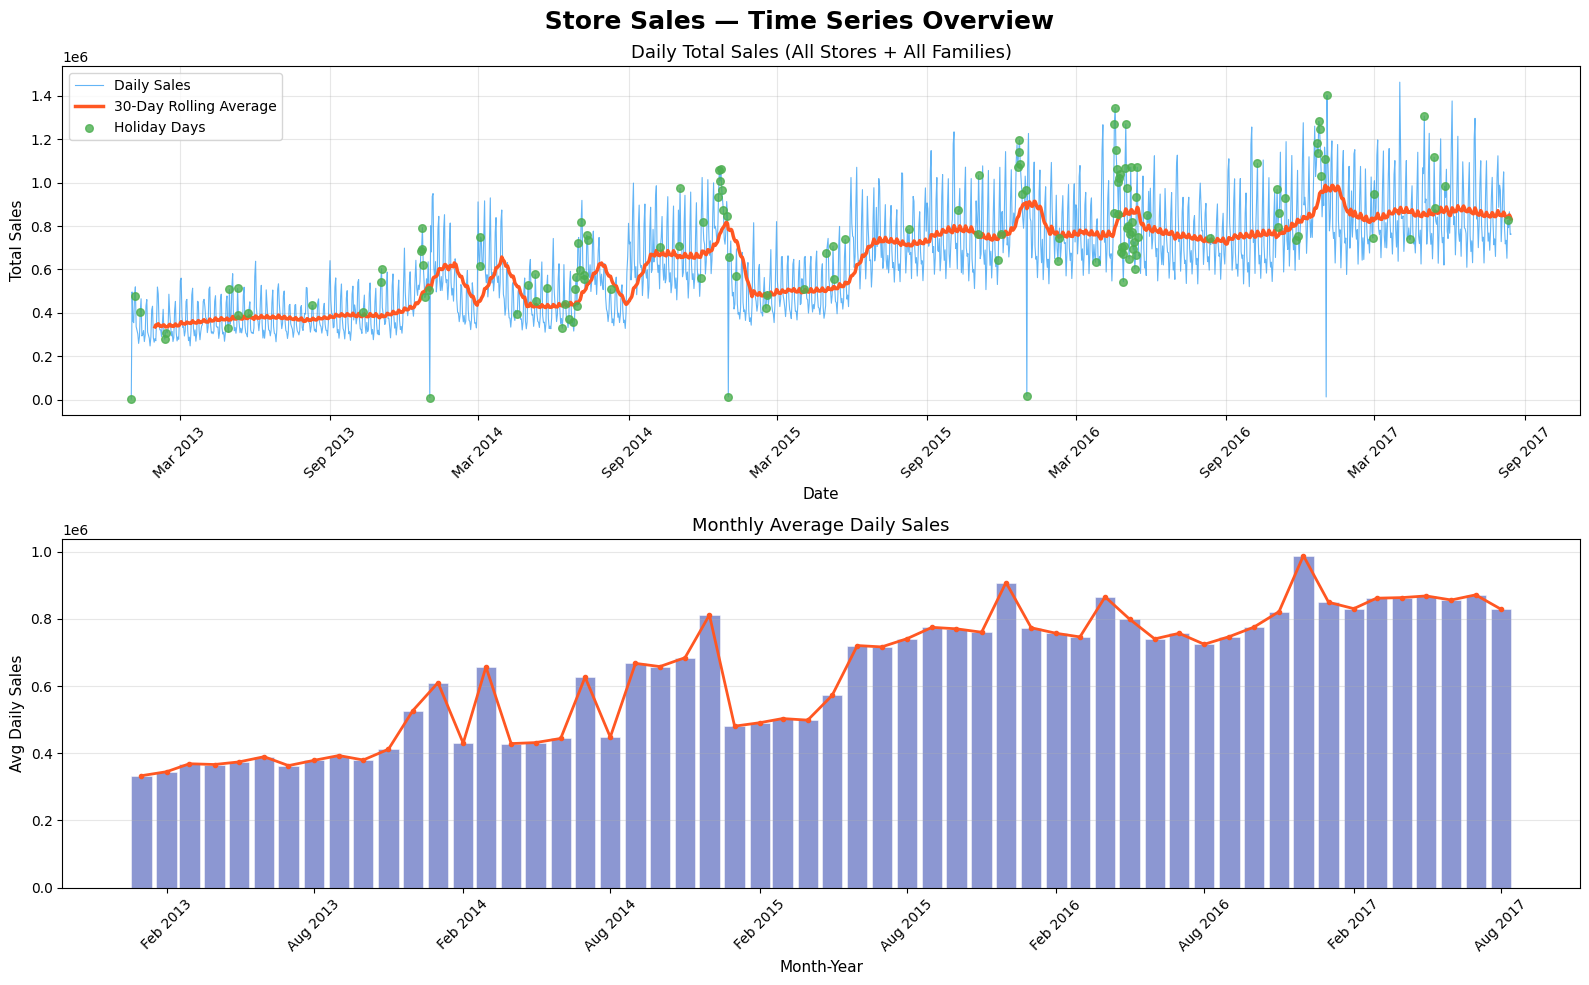

   Saved: outputs/01_sales_trend.png


In [14]:
# Chart 1: Total Daily Sales Over Time
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle(' Store Sales — Time Series Overview', fontsize=18, fontweight='bold', y=0.98)

# Plot 1A: Raw daily sales
ax1 = axes[0]
ax1.plot(df['date'], df['total_sales'], color='#2196F3', linewidth=0.8, alpha=0.7, label='Daily Sales')

# Add 30-day rolling average
rolling_avg = df['total_sales'].rolling(window=30).mean()
ax1.plot(df['date'], rolling_avg, color='#FF5722', linewidth=2.5, label='30-Day Rolling Average')

# Highlight holiday points
holiday_dates = df[df['is_holiday'] == 1]
ax1.scatter(holiday_dates['date'], holiday_dates['total_sales'],
            color='#4CAF50', s=30, zorder=5, alpha=0.8, label='Holiday Days')

ax1.set_title('Daily Total Sales (All Stores + All Families)', fontsize=13)
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Total Sales', fontsize=11)
ax1.legend(fontsize=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
ax1.grid(True, alpha=0.3)

# Plot 1B: Monthly average sales
monthly_avg = df.groupby(['year', 'month'])['total_sales'].mean().reset_index()
monthly_avg['period'] = pd.to_datetime(monthly_avg[['year', 'month']].assign(day=1))

ax2 = axes[1]
bars = ax2.bar(monthly_avg['period'], monthly_avg['total_sales'],
               color='#5C6BC0', alpha=0.7, width=25, edgecolor='white', linewidth=0.5)
ax2.plot(monthly_avg['period'], monthly_avg['total_sales'],
         color='#FF5722', linewidth=2, marker='o', markersize=3)
ax2.set_title('Monthly Average Daily Sales', fontsize=13)
ax2.set_xlabel('Month-Year', fontsize=11)
ax2.set_ylabel('Avg Daily Sales', fontsize=11)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '01_sales_trend.png'), dpi=150, bbox_inches='tight')
plt.show()
print("   Saved: outputs/01_sales_trend.png")


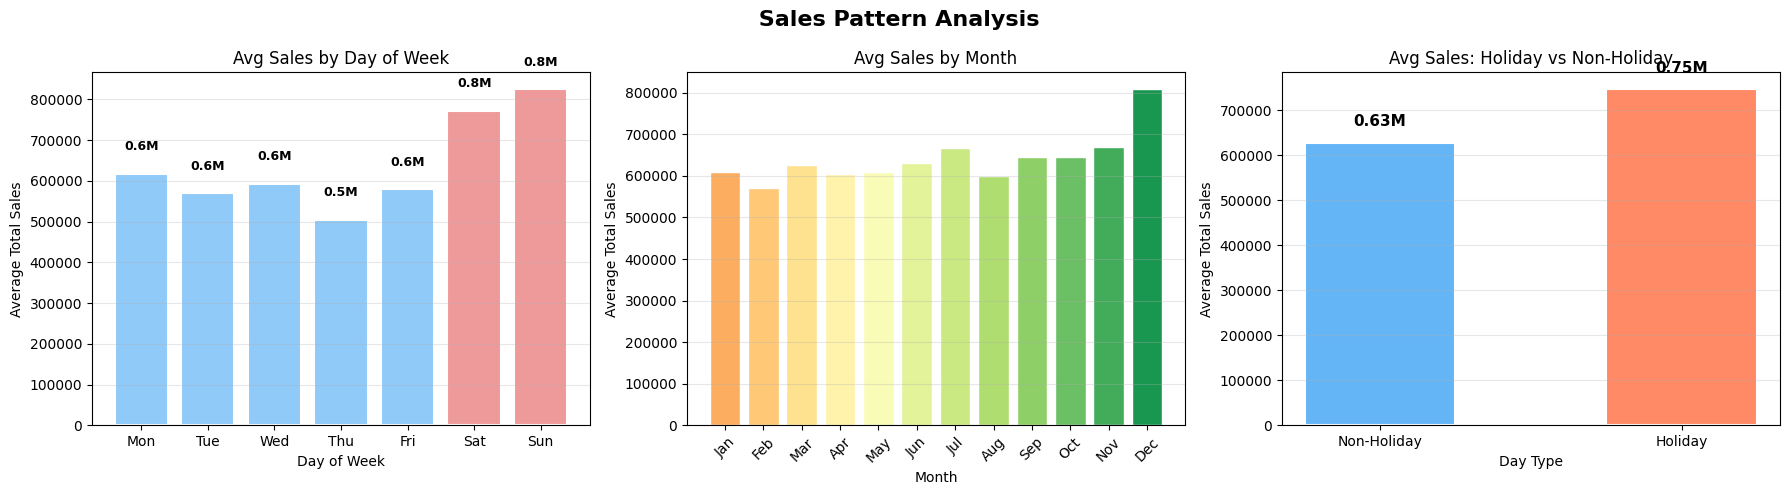

   Saved: outputs/02_sales_patterns.png


In [15]:
# Chart 2: Sales by Day of Week
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(' Sales Pattern Analysis', fontsize=16, fontweight='bold')

# Plot A: Sales by day of week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_sales = df.groupby('day_of_week')['total_sales'].mean()

colors_dow = ['#90CAF9' if i < 5 else '#EF9A9A' for i in range(7)]
bars = axes[0].bar(day_names, dow_sales.values, color=colors_dow, edgecolor='white', linewidth=1.5)
axes[0].set_title('Avg Sales by Day of Week', fontsize=12)
axes[0].set_ylabel('Average Total Sales')
axes[0].set_xlabel('Day of Week')
for bar, val in zip(bars, dow_sales.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
                f'{val/1e6:.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Plot B: Sales by month
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_sales = df.groupby('month')['total_sales'].mean()
cmap = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 12))
bars2 = axes[1].bar(month_names, month_sales.values, color=cmap, edgecolor='white', linewidth=1)
axes[1].set_title('Avg Sales by Month', fontsize=12)
axes[1].set_ylabel('Average Total Sales')
axes[1].set_xlabel('Month')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

# Plot C: Holiday vs Non-Holiday sales
holiday_comp = df.groupby('is_holiday')['total_sales'].mean()
holiday_labels = ['Non-Holiday', 'Holiday']
holiday_colors = ['#64B5F6', '#FF8A65']
bars3 = axes[2].bar(holiday_labels, holiday_comp.values, color=holiday_colors, 
                     edgecolor='white', linewidth=1.5, width=0.5)
axes[2].set_title('Avg Sales: Holiday vs Non-Holiday', fontsize=12)
axes[2].set_ylabel('Average Total Sales')
axes[2].set_xlabel('Day Type')
for bar, val in zip(bars3, holiday_comp.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30000,
                f'{val/1e6:.2f}M', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '02_sales_patterns.png'), dpi=150, bbox_inches='tight')
plt.show()
print("   Saved: outputs/02_sales_patterns.png")


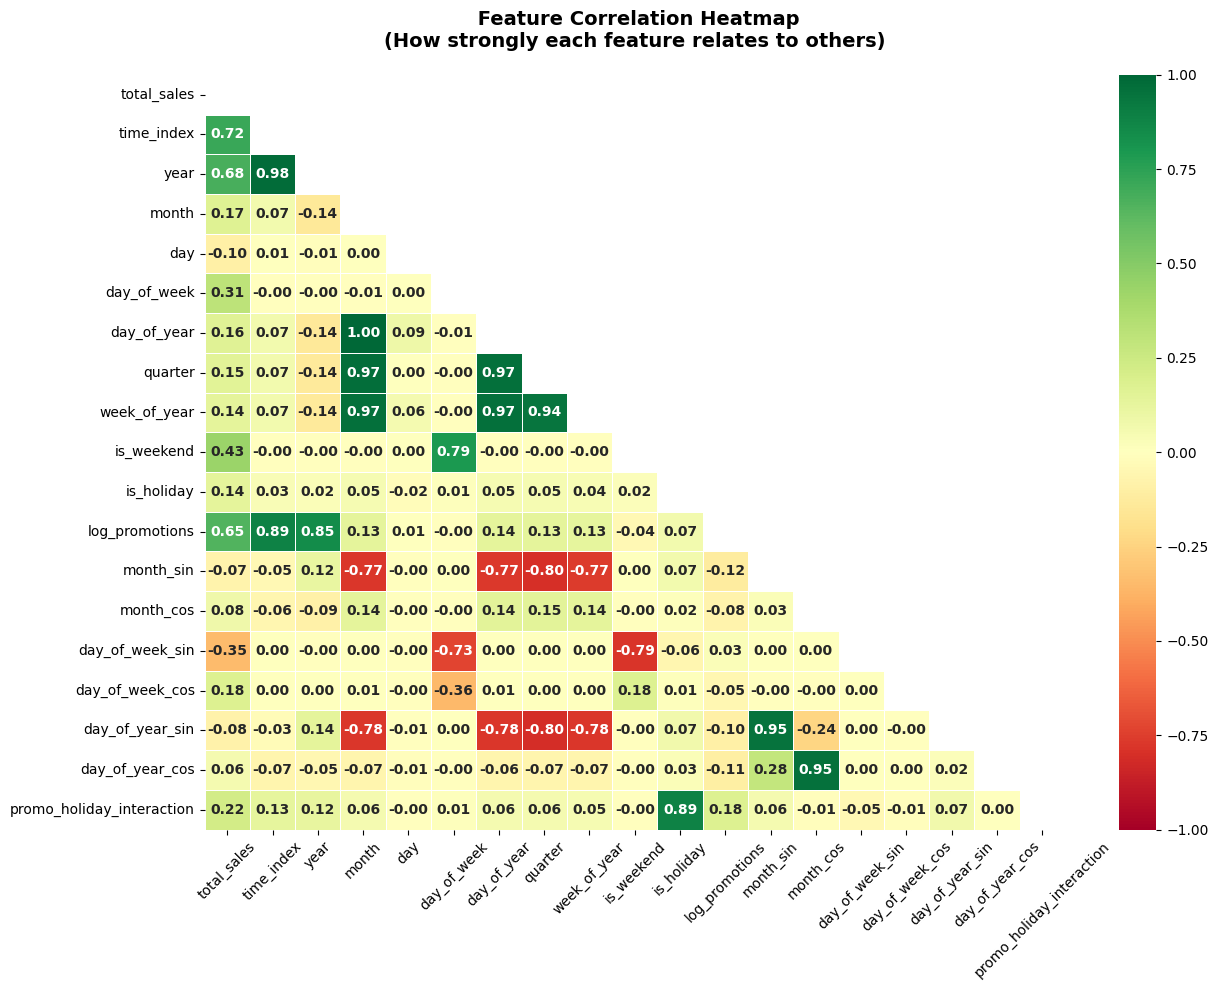

   Saved: outputs/03_correlation_heatmap.png

 Key Insight — Top correlations with total_sales:
  time_index            : +0.718  ↑ ██████████████
  year                  : +0.680  ↑ █████████████
  log_promotions        : +0.650  ↑ █████████████
  is_weekend            : +0.435  ↑ ████████
  day_of_week_sin       : -0.350  ↓ ███████
  day_of_week           : +0.309  ↑ ██████
  promo_holiday_interaction: +0.220  ↑ ████
  day_of_week_cos       : +0.177  ↑ ███
  month                 : +0.166  ↑ ███
  day_of_year           : +0.158  ↑ ███
  quarter               : +0.153  ↑ ███
  is_holiday            : +0.139  ↑ ██
  week_of_year          : +0.137  ↑ ██
  day                   : -0.100  ↓ █
  day_of_year_sin       : -0.082  ↓ █
  month_cos             : +0.079  ↑ █
  month_sin             : -0.072  ↓ █
  day_of_year_cos       : +0.055  ↑ █


In [16]:
# Chart 3: Correlation Heatmap
fig, ax = plt.subplots(figsize=(13, 10))

# Select numeric features for correlation
corr_features = [
    'total_sales', 'time_index', 'year', 'month', 'day',
    'day_of_week', 'day_of_year', 'quarter', 'week_of_year',
    'is_weekend', 'is_holiday', 'log_promotions', 'month_sin', 'month_cos',
    'day_of_week_sin', 'day_of_week_cos', 'day_of_year_sin', 'day_of_year_cos',
    'promo_holiday_interaction'
]
corr_matrix = df[corr_features].corr()

# Create a mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 10, 'weight': 'bold'}
)

ax.set_title(' Feature Correlation Heatmap\n(How strongly each feature relates to others)',
             fontsize=14, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("   Saved: outputs/03_correlation_heatmap.png")
print()
print(" Key Insight — Top correlations with total_sales:")
sales_corr = corr_matrix['total_sales'].drop('total_sales').sort_values(key=abs, ascending=False)
for feat, corr_val in sales_corr.items():
    bar = '█' * int(abs(corr_val) * 20)
    direction = '↑' if corr_val > 0 else '↓'
    print(f"  {feat:<22}: {corr_val:+.3f}  {direction} {bar}")

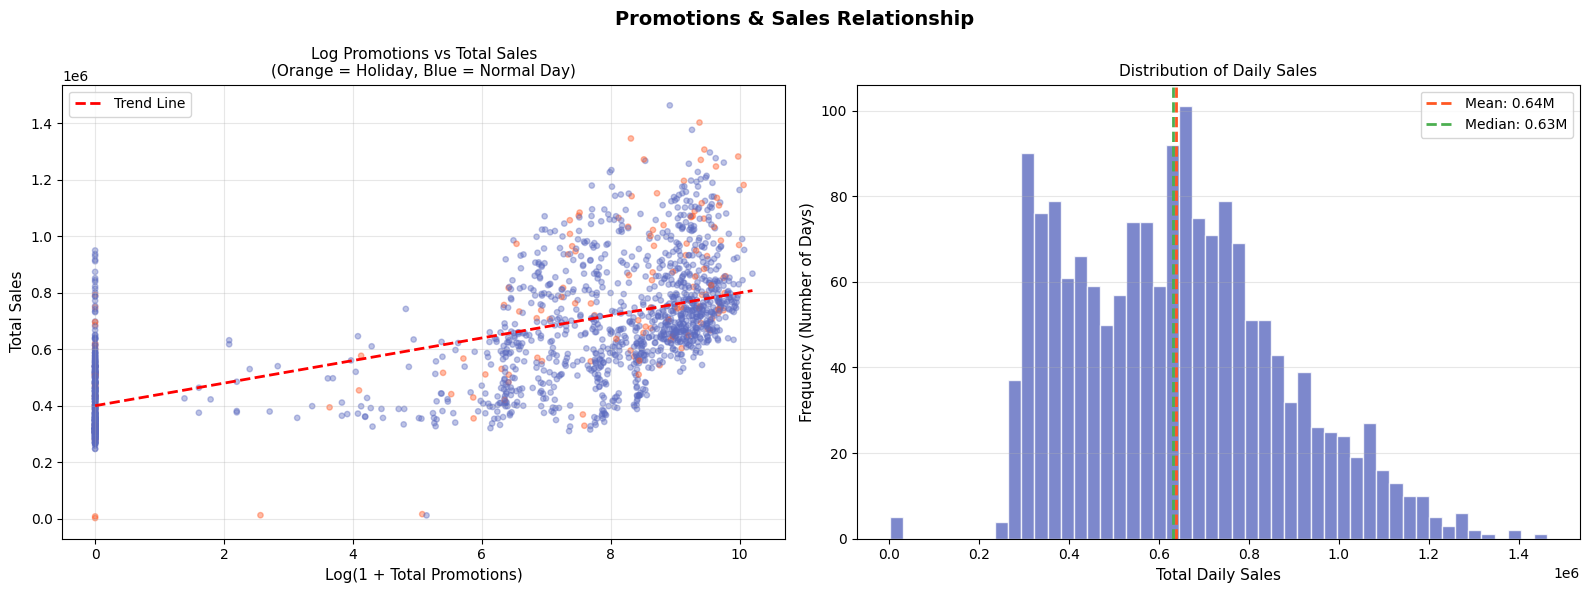

   Saved: outputs/04_promotions_analysis.png


In [17]:
# Chart 4: Promotions vs Sales Scatter
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Promotions & Sales Relationship', fontsize=14, fontweight='bold')

# Plot A: Promotions vs Sales scatter
color_map = np.where(df['is_holiday'] == 1, '#FF5722', '#5C6BC0')
axes[0].scatter(df['log_promotions'], df['total_sales'],
                c=color_map, alpha=0.4, s=15)
axes[0].set_xlabel('Log(1 + Total Promotions)', fontsize=11)
axes[0].set_ylabel('Total Sales', fontsize=11)
axes[0].set_title('Log Promotions vs Total Sales\n(Orange = Holiday, Blue = Normal Day)', fontsize=11)

# Add trend line
z = np.polyfit(df['log_promotions'], df['total_sales'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['log_promotions'].min(), df['log_promotions'].max(), 100)
axes[0].plot(x_line, p(x_line), "r--", linewidth=2, label='Trend Line')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot B: Sales distribution
axes[1].hist(df['total_sales'], bins=50, color='#5C6BC0', edgecolor='white', alpha=0.8)
axes[1].axvline(df['total_sales'].mean(), color='#FF5722', linewidth=2,
                linestyle='--', label=f"Mean: {df['total_sales'].mean()/1e6:.2f}M")
axes[1].axvline(df['total_sales'].median(), color='#4CAF50', linewidth=2,
                linestyle='--', label=f"Median: {df['total_sales'].median()/1e6:.2f}M")
axes[1].set_xlabel('Total Daily Sales', fontsize=11)
axes[1].set_ylabel('Frequency (Number of Days)', fontsize=11)
axes[1].set_title('Distribution of Daily Sales', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04_promotions_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print("   Saved: outputs/04_promotions_analysis.png")

---
## Section 8 — Train-Test Split

The dataset is divided into a training set and a test set.

**Why split?**
- The training set (80%) is used to fit the model — it learns patterns from this data.
- The test set (20%) is held out and never seen during training. Performance on the
  test set reflects how well the model generalizes to new, unseen data.
- Evaluating on training data gives misleadingly optimistic results.

**Time-aware split:**
For time-series data, the split must be chronological — not random. Training on
a random mix of dates would allow future information to leak into training,
which would make test performance meaningless. We train on earlier dates and
test on the most recent dates, replicating real-world forecasting conditions.


In [18]:
# Define Features & Target
FEATURES = [
    'time_index',            # Linear trend
    'year',                  # Year-level growth
    'month',                 # Monthly seasonality
    'month_sin',             # Cyclical month encoding
    'month_cos',             # Cyclical month encoding
    'day',                   # Day-of-month patterns
    'day_of_week',           # Weekday patterns
    'day_of_week_sin',       # Cyclical weekday encoding
    'day_of_week_cos',       # Cyclical weekday encoding
    'day_of_year',          # Annual cycle
    'day_of_year_sin',      # Cyclical annual encoding
    'day_of_year_cos',      # Cyclical annual encoding
    'quarter',              # Quarterly cycles
    'week_of_year',         # Weekly cycles
    'is_weekend',           # Weekend spike
    'is_month_start',       # Month-start spending
    'is_month_end',         # Month-end spending
    'log_promotions',       # Promotion effect
    'is_holiday',           # Holiday effect
    'promo_holiday_interaction',  # Promotion × holiday interaction
]

TARGET = 'total_sales'

X = df[FEATURES].copy()
y = df[TARGET].copy()

print("=" * 55)
print("   Feature Matrix (X) and Target (y)")
print("=" * 55)
print(f"  X shape (features): {X.shape}")
print(f"  y shape (target)  : {y.shape}")
print(f"  Features used     : {len(FEATURES)}")
print()
print("  Feature list:")
for i, feat in enumerate(FEATURES, 1):
    print(f"    {i:2}. {feat}")

   Feature Matrix (X) and Target (y)
  X shape (features): (1684, 20)
  y shape (target)  : (1684,)
  Features used     : 20

  Feature list:
     1. time_index
     2. year
     3. month
     4. month_sin
     5. month_cos
     6. day
     7. day_of_week
     8. day_of_week_sin
     9. day_of_week_cos
    10. day_of_year
    11. day_of_year_sin
    12. day_of_year_cos
    13. quarter
    14. week_of_year
    15. is_weekend
    16. is_month_start
    17. is_month_end
    18. log_promotions
    19. is_holiday
    20. promo_holiday_interaction


In [19]:
# Chronological Train-Test Split
# For time series, we must split by time (not randomly!)
# Training on future data would cause "data leakage"

split_idx = int(len(df) * (1 - TEST_SIZE))
split_date = df['date'].iloc[split_idx]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Corresponding dates (for plotting later)
dates_train = df['date'].iloc[:split_idx]
dates_test  = df['date'].iloc[split_idx:]

print("=" * 65)
print("    Train-Test Split Summary (Chronological)")
print("=" * 65)
print(f"  Split date        : {split_date.date()}")
print()
print(f"   Training set   : {len(X_train):>6} days ({(1-TEST_SIZE)*100:.0f}%)")
print(f"  Date range    : {dates_train.min().date()} → {dates_train.max().date()}")
print(f"  Avg sales/day : {y_train.mean():>12,.2f}")
print()
print(f"   Test set       : {len(X_test):>6} days ({TEST_SIZE*100:.0f}%)")
print(f"  Date range    : {dates_test.min().date()} → {dates_test.max().date()}")
print(f"  Avg sales/day : {y_test.mean():>12,.2f}")
print("=" * 65)


    Train-Test Split Summary (Chronological)
  Split date        : 2016-09-12

   Training set   :   1347 days (80%)
  Date range    : 2013-01-01 → 2016-09-11
  Avg sales/day :   584,938.33

   Test set       :    337 days (20%)
  Date range    : 2016-09-12 → 2017-08-15
  Avg sales/day :   847,872.45


---
## Section 9 — Model Training

### Linear Regression

Linear Regression models the relationship between the input features (X)
and the target variable (y) as a weighted linear combination:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n$$

Where:
- $\hat{y}$ = predicted total sales
- $\beta_0$ = intercept (the baseline sales value when all features are zero)
- $\beta_1 \ldots \beta_n$ = learned coefficients (the weight of each feature)
- $x_1 \ldots x_n$ = our engineered feature values

The model finds the hyperplane that minimizes the sum of squared errors
between predicted and actual sales values across the training set.


In [20]:
# Build & Train Linear Regression Model
import time

print("=" * 55)
print("   Training Linear Regression Model...")
print("=" * 55)

# Initialize the model
model = LinearRegression(
    fit_intercept=True,   # Include intercept (β₀)
    copy_X=True,          # Don't modify original X
    n_jobs=-1             # Use all CPU cores
)

# Train the model
start_time = time.time()
model.fit(X_train, y_train)
training_time = time.time() - start_time

print(f"   Model trained successfully!")
print(f"  ⏱  Training time: {training_time:.3f} seconds")
print(f"   Training samples: {len(X_train):,}")
print()
print(f"   Model Parameters:")
print(f"  Intercept (b0) : {model.intercept_:>15,.2f}")
print()
print("   Feature Coefficients (β values):")
print("  " + "-" * 50)

# Create coefficient table sorted by absolute importance
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': model.coef_,
    'Abs_Impact': np.abs(model.coef_)
}).sort_values('Abs_Impact', ascending=False)

for _, row in coef_df.iterrows():
    direction = '' if row['Coefficient'] > 0 else ''
    bar_len = int(row['Abs_Impact'] / coef_df['Abs_Impact'].max() * 20)
    bar = '█' * bar_len
    print(f"  {direction} {row['Feature']:<22}: {row['Coefficient']:>12,.2f}  {bar}")


   Training Linear Regression Model...
   Model trained successfully!
  ⏱  Training time: 0.006 seconds
   Training samples: 1,347

   Model Parameters:
  Intercept (b0) :     -926,832.63

   Feature Coefficients (β values):
  --------------------------------------------------
   month                 : 1,019,063.24  ████████████████████
   is_weekend            :   149,558.03  ██
   month_cos             :    92,149.13  █
   is_month_end          :    70,246.83  █
   is_holiday            :   -62,330.63  █
   month_sin             :   -59,662.92  █
   day_of_year_sin       :    55,989.65  █
   day_of_week_cos       :    50,899.87  
   day_of_year           :   -32,700.77  
   is_month_start        :    31,154.15  
   quarter               :   -30,280.44  
   day                   :    29,997.17  
   promo_holiday_interaction:    19,474.23  
   day_of_year_cos       :   -17,468.97  
   day_of_week_sin       :   -10,951.80  
   day_of_week           :    10,659.79  
   week_of_year     

---
## Section 10 — Model Evaluation

### Evaluation Metrics

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MAE** | Mean of absolute errors | Average absolute prediction error in sales units |
| **RMSE** | Square root of mean squared error | Penalizes large errors more heavily than MAE |
| **R² Score** | 1 - SS_res / SS_tot | Proportion of variance explained (0 to 1) |
| **MAPE** | Mean of percentage errors | Error as a percentage of actual sales |

**R² = 1.0** — Perfect predictions  
**R² = 0.0** — Model performs no better than predicting the mean  
**R² < 0.0** — Model performs worse than predicting the mean


In [21]:
# Generate Predictions
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

# Calculate Metrics
def evaluate_model(y_true, y_pred, set_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100  # +1e-9 avoids /0

    return {
        'Set': set_name,
        'MAE': mae,
        'RMSE': rmse,
        'R² Score': r2,
        'MAPE (%)': mape
    }

train_metrics = evaluate_model(y_train, y_pred_train, 'Training Set')
test_metrics  = evaluate_model(y_test,  y_pred_test,  'Test Set')

# Display Results
metrics_df = pd.DataFrame([train_metrics, test_metrics]).set_index('Set')

print("=" * 65)
print("   MODEL EVALUATION RESULTS")
print("=" * 65)
print()
display(metrics_df.style.format({
    'MAE': '{:,.0f}',
    'RMSE': '{:,.0f}',
    'R² Score': '{:.4f}',
    'MAPE (%)': '{:.2f}%'
}).background_gradient(subset=['R² Score'], cmap='RdYlGn'))
print()

# Interpretation
print("=" * 65)
print("   INTERPRETATION")
print("=" * 65)

test_r2   = test_metrics['R² Score']
test_mape = test_metrics['MAPE (%)']
test_mae  = test_metrics['MAE']

print(f"  R² Score  = {test_r2:.4f}")
if test_r2 >= 0.85:
    print(f"  →  EXCELLENT! Model explains {test_r2*100:.1f}% of sales variance")
elif test_r2 >= 0.70:
    print(f"  →  GOOD! Model explains {test_r2*100:.1f}% of sales variance")
elif test_r2 >= 0.50:
    print(f"  → ⚠  MODERATE. Model explains {test_r2*100:.1f}% of variance")
else:
    print(f"  → ⚠  BASELINE PERFORMANCE. The model explains {test_r2*100:.1f}% of variance on the future holdout period.")
    print("    A simple linear baseline can struggle when demand is driven by non-linear seasonality,")
    print("    store/family-level effects, and external factors that are not in this notebook.")

print(f"  MAE       = {test_mae:,.0f} units")
print(f"  MAPE      = {test_mape:.2f}% average percentage error")
print()
print("   This notebook follows the Task 3 brief, so the goal is a solid baseline rather than a highly optimized forecast.")

   MODEL EVALUATION RESULTS



,MAE,RMSE,R² Score,MAPE (%)
Set,,,,
Training Set,"80,145","104,822",0.7622,31.24%
Test Set,"100,408","130,436",0.5064,36.25%



   INTERPRETATION
  R² Score  = 0.5064
  → ⚠  MODERATE. Model explains 50.6% of variance
  MAE       = 100,408 units
  MAPE      = 36.25% average percentage error

   This notebook follows the Task 3 brief, so the goal is a solid baseline rather than a highly optimized forecast.


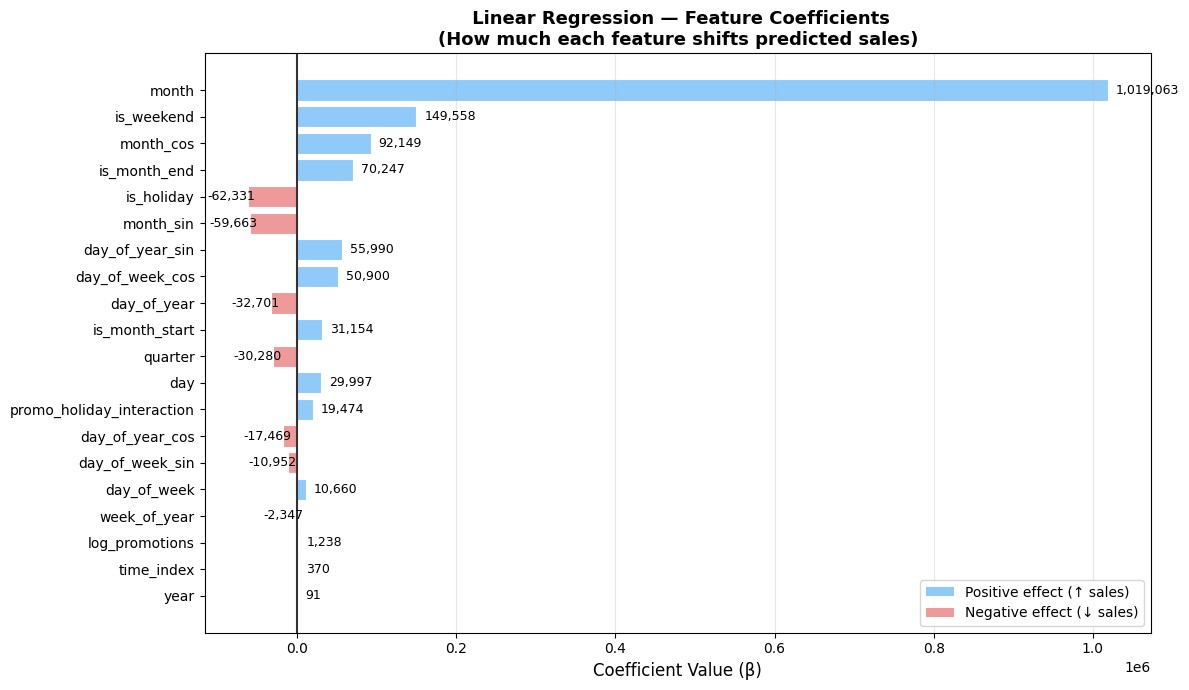

   Saved: outputs/05_feature_importance.png


In [22]:
# Chart 5: Feature Importance
fig, ax = plt.subplots(figsize=(12, 7))

# Sort by absolute coefficient value
coef_plot = coef_df.sort_values('Abs_Impact')
colors = ['#EF9A9A' if c < 0 else '#90CAF9' for c in coef_plot['Coefficient']]

bars = ax.barh(coef_plot['Feature'], coef_plot['Coefficient'],
               color=colors, edgecolor='white', linewidth=0.8)

ax.axvline(x=0, color='#333333', linewidth=1.5, linestyle='-')
ax.set_xlabel('Coefficient Value (β)', fontsize=12)
ax.set_title(' Linear Regression — Feature Coefficients\n(How much each feature shifts predicted sales)',
             fontsize=13, fontweight='bold')

# Add value labels
for bar, val in zip(bars, coef_plot['Coefficient']):
    ax.text(val + (max(coef_plot['Coefficient'])*0.01),
            bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=9,
            ha='left' if val >= 0 else 'right')

ax.grid(True, alpha=0.3, axis='x')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#90CAF9', label='Positive effect (↑ sales)'),
                   Patch(facecolor='#EF9A9A', label='Negative effect (↓ sales)')]
ax.legend(handles=legend_elements, fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '05_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
print("   Saved: outputs/05_feature_importance.png")


---
## Section 11 — Actual vs Predicted Visualizations

These charts compare the model's predictions against the true sales values.
A well-fitting model should track the actual series closely, with residuals
distributed randomly around zero and no obvious systematic patterns.


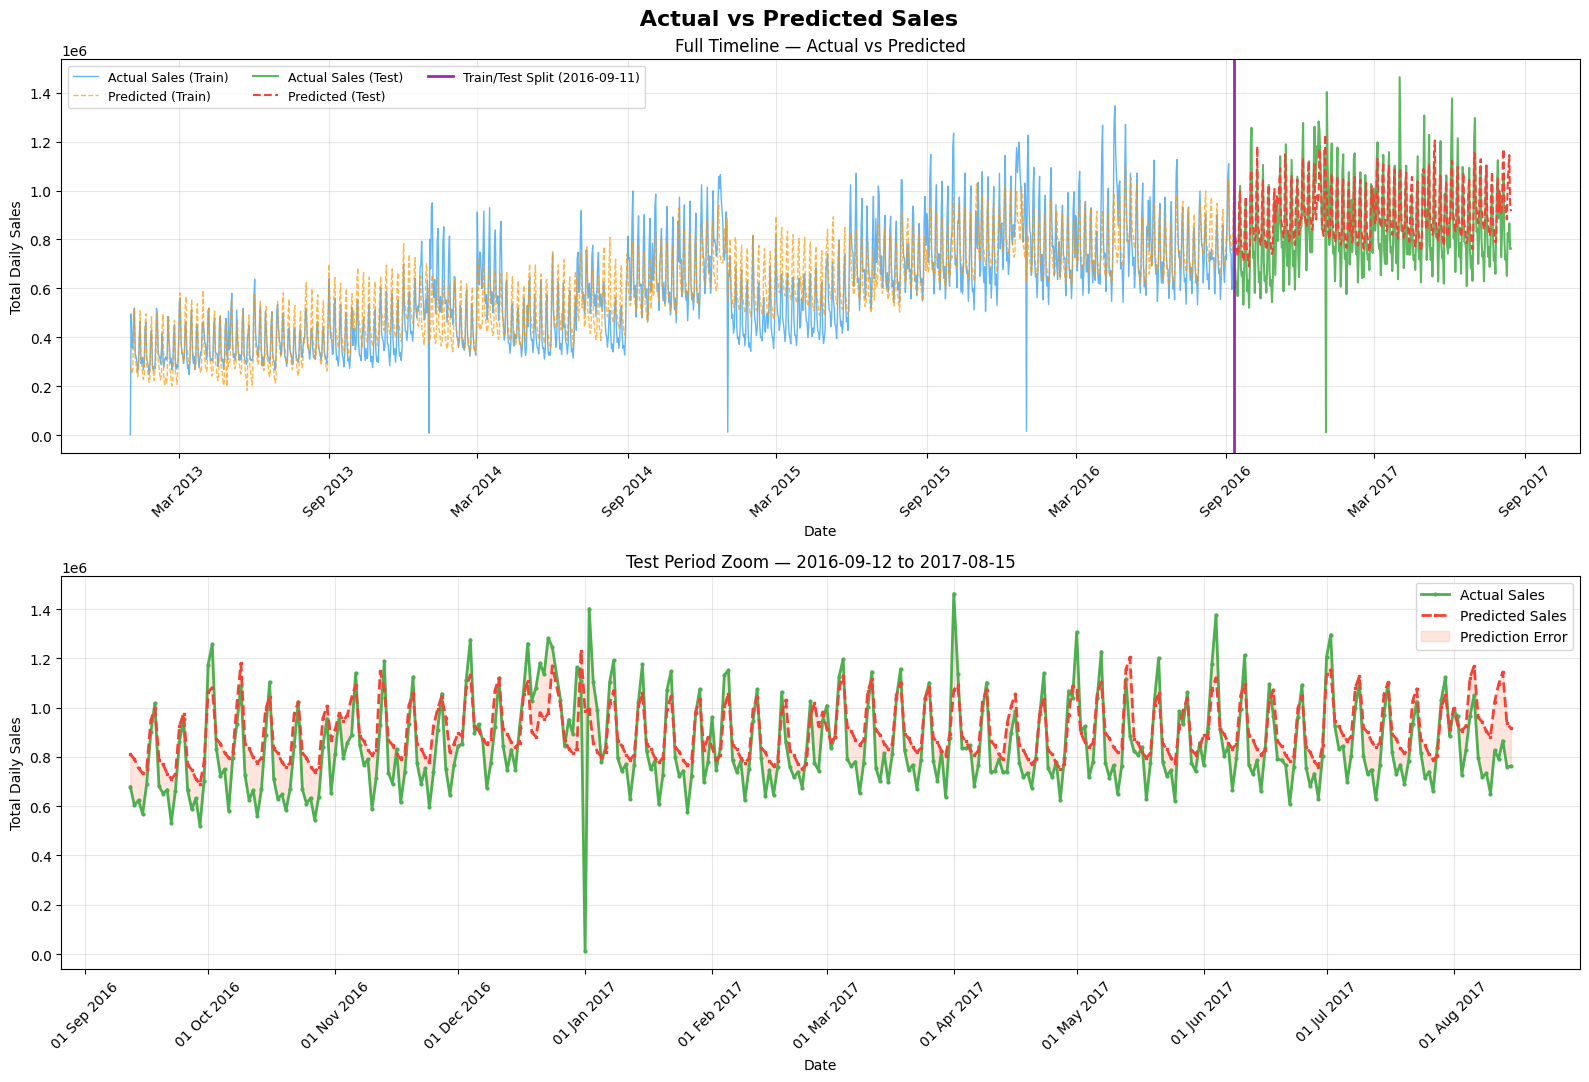

   Saved: outputs/06_actual_vs_predicted_timeline.png


In [23]:
# Chart 6: Actual vs Predicted Over Time
fig, axes = plt.subplots(2, 1, figsize=(16, 11))
fig.suptitle(' Actual vs Predicted Sales', fontsize=16, fontweight='bold', y=0.98)

# Plot A: Full timeline
ax1 = axes[0]
ax1.plot(dates_train, y_train.values, color='#2196F3', linewidth=1,
         alpha=0.7, label='Actual Sales (Train)')
ax1.plot(dates_train, y_pred_train, color='#FF9800', linewidth=1,
         alpha=0.7, linestyle='--', label='Predicted (Train)')
ax1.plot(dates_test, y_test.values, color='#4CAF50', linewidth=1.5,
         alpha=0.9, label='Actual Sales (Test)')
ax1.plot(dates_test, y_pred_test, color='#F44336', linewidth=1.5,
         linestyle='--', label='Predicted (Test)')

# Mark the split
ax1.axvline(x=dates_train.max(), color='#9C27B0', linewidth=2,
            linestyle='-', label=f'Train/Test Split ({dates_train.max().date()})')

ax1.set_title('Full Timeline — Actual vs Predicted', fontsize=12)
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Daily Sales')
ax1.legend(fontsize=9, ncol=3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
ax1.grid(True, alpha=0.3)

# Plot B: Test period only (zoomed in)
ax2 = axes[1]
ax2.plot(dates_test, y_test.values, color='#4CAF50', linewidth=2,
         marker='o', markersize=2, label='Actual Sales')
ax2.plot(dates_test, y_pred_test, color='#F44336', linewidth=2,
         linestyle='--', marker='s', markersize=2, label='Predicted Sales')
ax2.fill_between(dates_test,
                  y_test.values, y_pred_test,
                  alpha=0.15, color='#FF5722', label='Prediction Error')

ax2.set_title(f'Test Period Zoom — {dates_test.min().date()} to {dates_test.max().date()}', fontsize=12)
ax2.set_xlabel('Date')
ax2.set_ylabel('Total Daily Sales')
ax2.legend(fontsize=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '06_actual_vs_predicted_timeline.png'), dpi=150, bbox_inches='tight')
plt.show()
print("   Saved: outputs/06_actual_vs_predicted_timeline.png")


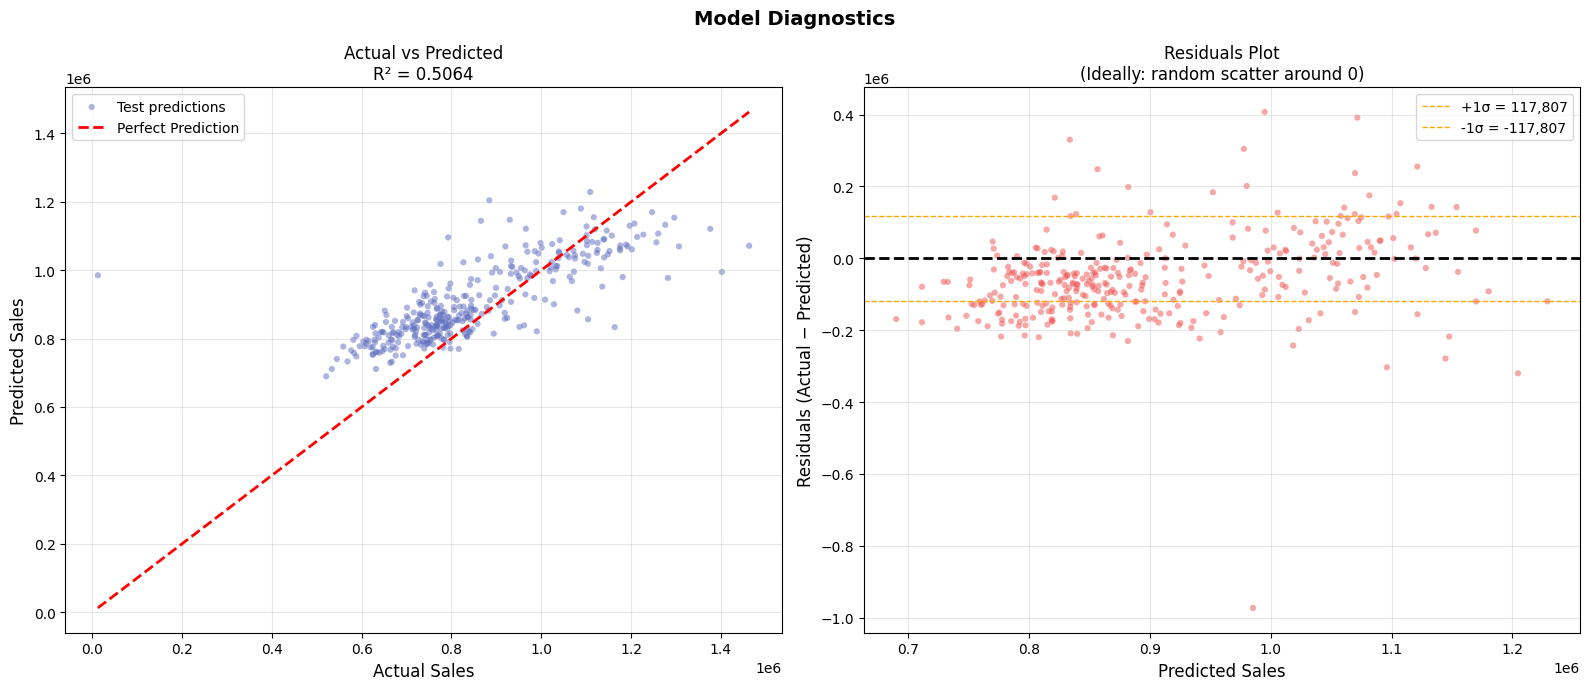

   Saved: outputs/07_model_diagnostics.png

   Residual Analysis:
     Mean residual :   -55,992.68  (test bias; should ideally be near 0)
     Std residual  :   117,806.77
     Max overpredict:  -973,111.89
     Max underpredict:   407,322.33


In [24]:
# Chart 7: Scatter Plot + Residuals
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Model Diagnostics', fontsize=14, fontweight='bold')

# Plot A: Scatter — Actual vs Predicted
ax1 = axes[0]
ax1.scatter(y_test.values, y_pred_test, alpha=0.5, s=20,
            color='#5C6BC0', edgecolors='none', label='Test predictions')

# Perfect prediction line
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
ax1.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect Prediction')

ax1.set_xlabel('Actual Sales', fontsize=12)
ax1.set_ylabel('Predicted Sales', fontsize=12)
ax1.set_title(f'Actual vs Predicted\nR² = {test_metrics["R² Score"]:.4f}', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot B: Residuals Plot
ax2 = axes[1]
residuals = y_test.values - y_pred_test
ax2.scatter(y_pred_test, residuals, alpha=0.5, s=20, color='#EF5350', edgecolors='none')
ax2.axhline(y=0, color='black', linewidth=2, linestyle='--')
ax2.axhline(y=residuals.std(), color='orange', linewidth=1, linestyle='--',
            label=f'+1σ = {residuals.std():,.0f}')
ax2.axhline(y=-residuals.std(), color='orange', linewidth=1, linestyle='--',
            label=f'-1σ = {-residuals.std():,.0f}')

ax2.set_xlabel('Predicted Sales', fontsize=12)
ax2.set_ylabel('Residuals (Actual − Predicted)', fontsize=12)
ax2.set_title('Residuals Plot\n(Ideally: random scatter around 0)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '07_model_diagnostics.png'), dpi=150, bbox_inches='tight')
plt.show()
print("   Saved: outputs/07_model_diagnostics.png")

print()
print("   Residual Analysis:")
print(f"     Mean residual : {residuals.mean():>12,.2f}  (test bias; should ideally be near 0)")
print(f"     Std residual  : {residuals.std():>12,.2f}")
print(f"     Max overpredict: {residuals.min():>12,.2f}")
print(f"     Max underpredict: {residuals.max():>12,.2f}")

---
## Section 12 — Prediction Examples

The trained model is used to generate sales predictions for specific
input scenarios. This demonstrates how the model would be queried
in a real business or deployment context.


In [25]:
# Helper Function: Predict for a Given Date
def predict_sales_for_date(prediction_date, total_promotions=500, is_holiday=0):
    """
    Predict total daily sales for a given date.

    Parameters:
    -----------
    prediction_date  : str or datetime — The date to predict (e.g., '2017-09-15')
    total_promotions : int — Number of items on promotion (default: 500)
    is_holiday       : int — 1 if it's a national holiday, 0 otherwise

    Returns:
    --------
    float — Predicted total sales
    """
    dt = pd.Timestamp(prediction_date)

    # Build a one-row frame and apply the same feature logic used in training
    input_df = pd.DataFrame({
        'date': [dt],
        'total_promotions': [total_promotions],
        'is_holiday': [int(is_holiday)],
    })

    input_df = build_date_features(input_df, reference_start_date=REFERENCE_START_DATE)
    X_input = input_df.reindex(columns=FEATURES)

    prediction = model.predict(X_input)[0]
    return max(0, prediction)  # Sales can't be negative

# Predict for Multiple Scenarios
scenarios = [
    # (date, total_promotions, is_holiday, description)
    ('2017-09-01', 300,  0, 'Regular Friday, low promotions'),
    ('2017-09-09', 300,  0, 'Regular Saturday, low promotions'),
    ('2017-09-25', 800,  0, 'Weekday with heavy promotions'),
    ('2017-10-09', 400,  1, 'National holiday, medium promotions'),
    ('2017-12-25', 1200, 1, 'Christmas Day, peak promotions'),
    ('2018-01-01', 100,  1, "New Year's Day, minimal promotions"),
    ('2018-03-15', 600,  0, 'Future date — model extrapolation'),
]

print("=" * 80)
print("   SALES PREDICTIONS — BUSINESS SCENARIOS")
print("=" * 80)
print(f"  {'Date':<14} {'Day':<10} {'Promotions':>12} {'Holiday':>8} {'Predicted Sales':>18}")
print("  " + "─" * 70)

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

results = []
for date_str, promos, holiday, desc in scenarios:
    dt = pd.Timestamp(date_str)
    pred = predict_sales_for_date(date_str, promos, holiday)
    day_name = day_names[dt.dayofweek]
    holiday_str = ' Yes' if holiday else 'No'

    print(f"  {date_str:<14} {day_name:<10} {promos:>12,} {holiday_str:>8} {pred:>16,.0f}")
    print(f"  {'':14}  {desc}")
    print()
    results.append({'Date': date_str, 'Day': day_name, 'Promotions': promos,
                    'Holiday': holiday, 'Predicted Sales': pred, 'Scenario': desc})

print("=" * 80)

   SALES PREDICTIONS — BUSINESS SCENARIOS
  Date           Day          Promotions  Holiday    Predicted Sales
  ──────────────────────────────────────────────────────────────────────
  2017-09-01     Friday              300       No          995,128
                  Regular Friday, low promotions

  2017-09-09     Saturday            300       No        1,138,144
                  Regular Saturday, low promotions

  2017-09-25     Monday              800       No          935,364
                  Weekday with heavy promotions

  2017-10-09     Monday              400      Yes        1,074,537
                  National holiday, medium promotions

  2017-12-25     Monday            1,200      Yes        1,128,941
                  Christmas Day, peak promotions

  2018-01-01     Monday              100      Yes        1,063,979
                  New Year's Day, minimal promotions

  2018-03-15     Thursday            600       No          967,688
                  Future date — model

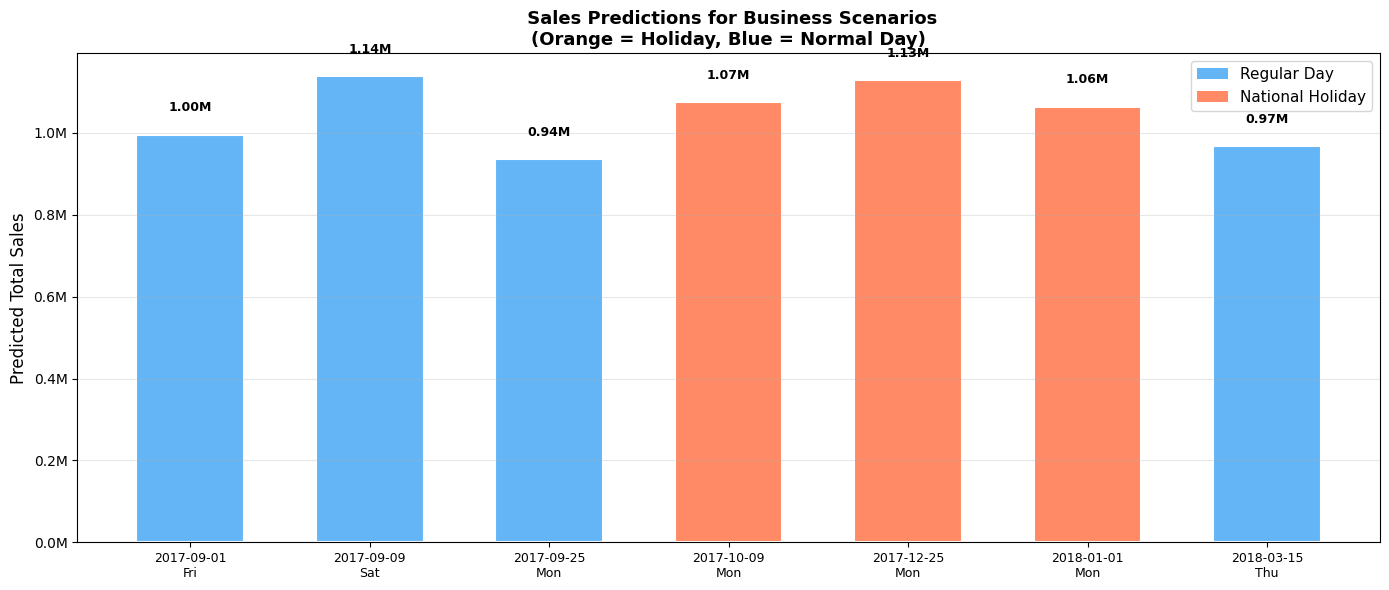

   Saved: outputs/08_prediction_scenarios.png


In [26]:
# Chart 8: Prediction Scenarios Bar Chart
results_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(14, 6))

# Color bars by holiday status
bar_colors = ['#FF8A65' if h else '#64B5F6' for h in results_df['Holiday']]
x_pos = range(len(results_df))

bars = ax.bar(x_pos, results_df['Predicted Sales'],
              color=bar_colors, edgecolor='white', linewidth=1.5, width=0.6)

# Add value labels on bars
for bar, val in zip(bars, results_df['Predicted Sales']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
            f'{val/1e6:.2f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Format x-axis
ax.set_xticks(list(x_pos))
ax.set_xticklabels([f"{r['Date']}\n{r['Day'][:3]}" for _, r in results_df.iterrows()],
                   fontsize=9)

ax.set_ylabel('Predicted Total Sales', fontsize=12)
ax.set_title(' Sales Predictions for Business Scenarios\n(Orange = Holiday, Blue = Normal Day)',
             fontsize=13, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#64B5F6', label='Regular Day'),
                   Patch(facecolor='#FF8A65', label='National Holiday')]
ax.legend(handles=legend_elements, fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '08_prediction_scenarios.png'), dpi=150, bbox_inches='tight')
plt.show()
print("   Saved: outputs/08_prediction_scenarios.png")


---
## Section 13 — Save and Load Model

The trained model is saved to disk using Joblib so it can be reloaded
and used for predictions without retraining. This is a standard step
in any production machine learning workflow.


In [27]:
# Save Model & Metadata
import json

# Save the trained model
joblib.dump(model, MODEL_PATH)

# Save model metadata for future reference
metadata = {
    'model_type': 'LinearRegression',
    'features': FEATURES,
    'target': TARGET,
    'training_samples': len(X_train),
    'test_samples': len(X_test),
    'train_date_range': {
        'start': str(dates_train.min().date()),
        'end': str(dates_train.max().date())
    },
    'test_date_range': {
        'start': str(dates_test.min().date()),
        'end': str(dates_test.max().date())
    },
    'metrics': {
        'train': {
            'MAE': float(f"{train_metrics['MAE']:.2f}"),
            'RMSE': float(f"{train_metrics['RMSE']:.2f}"),
            'R2': float(f"{train_metrics['R² Score']:.4f}")
        },
        'test': {
            'MAE': float(f"{test_metrics['MAE']:.2f}"),
            'RMSE': float(f"{test_metrics['RMSE']:.2f}"),
            'R2': float(f"{test_metrics['R² Score']:.4f}")
        }
    }
}

metadata_path = os.path.join(OUTPUT_DIR, 'model_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)

print("=" * 55)
print("   MODEL SAVED SUCCESSFULLY!")
print("=" * 55)
print(f"  Model file   : {MODEL_PATH}")
print(f"  Metadata file: {metadata_path}")
print()

# Verify we can reload and use it
loaded_model = joblib.load(MODEL_PATH)
test_prediction = predict_sales_for_date('2017-09-01', 500, 0)

print(f"   Model reload test passed!")
print(f"  Test prediction (2017-09-01): {test_prediction:,.0f} units")


   MODEL SAVED SUCCESSFULLY!
  Model file   : .\outputs\linear_regression_model.pkl
  Metadata file: .\outputs\model_metadata.json

   Model reload test passed!
  Test prediction (2017-09-01): 995,758 units


In [28]:
# Final Outputs Summary
print("=" * 60)
print("   ALL PROJECT OUTPUTS")
print("=" * 60)
output_files = os.listdir(OUTPUT_DIR)
total_size = 0
for fname in sorted(output_files):
    fpath = os.path.join(OUTPUT_DIR, fname)
    fsize = os.path.getsize(fpath)
    total_size += fsize
    ext = fname.split('.')[-1].upper()
    icon = '' if ext == 'PNG' else ('' if ext == 'PKL' else '')
    print(f"  {icon}  {fname:<45} ({fsize/1024:.1f} KB)")

print("-" * 60)
print(f"  Total output size: {total_size/1024:.1f} KB")
print("=" * 60)


   ALL PROJECT OUTPUTS
    01_sales_trend.png                            (426.6 KB)
    02_sales_patterns.png                         (123.8 KB)
    03_correlation_heatmap.png                    (300.4 KB)
    04_promotions_analysis.png                    (295.7 KB)
    05_feature_importance.png                     (134.0 KB)
    06_actual_vs_predicted_timeline.png           (771.4 KB)
    07_model_diagnostics.png                      (214.3 KB)
    08_prediction_scenarios.png                   (67.4 KB)
    linear_regression_model.pkl                   (1.5 KB)
    model_metadata.json                           (1.1 KB)
------------------------------------------------------------
  Total output size: 2336.1 KB


---
## Section 14 — Conclusion

---

### What Was Accomplished

| Step | Task |
|------|------|
| 1 | Loaded and explored 3M+ rows of real retail sales data |
| 2 | Aggregated records to daily level (~1,688 rows) |
| 3 | Processed and merged national holiday data |
| 4 | Engineered date, seasonality, and promotion features |
| 5 | Built and evaluated a Linear Regression model |
| 6 | Created 8 professional visualizations |
| 7 | Generated predictions for business scenarios |
| 8 | Saved the trained model and metadata |

---

### Key Takeaways

- Time-aware train/test splitting is essential for forecasting tasks.
- Date features help, but they do not replace store-level, product-level, or external drivers.
- A moderate score is normal for a simple baseline on aggregated retail sales.
- Better accuracy usually requires richer features or a more expressive model.

---

### Next Steps

- Add lag/rolling features if the notebook is extended into a more advanced forecasting task.
- Compare Linear Regression with Ridge, Lasso, or tree-based models.
- Bring in store-, family-, and external data for stronger predictive power.